<a href="https://colab.research.google.com/github/ian-menachery/ECON3916-Statistical-Machine-Learning/blob/main/Lab2_Fred_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred

# Authenticate
# Replace the string below with YOUR unique API key from fred.stlouisfed.org
fred = Fred(api_key='')

In [7]:
# 1. Fetch the data series
print("Fetching data from FRED...")
wages = fred.get_series('AHETPI')
cpi = fred.get_series('CPIAUCSL')

# 2. Combine into a DataFrame
df = pd.DataFrame({'Nominal_Wage': wages, 'CPI': cpi})

# 3. Drop missing values (The wage data starts later than CPI data)
df = df.dropna()

# Inspect the raw data
print(df.head())
print(df.tail())

Fetching data from FRED...
            Nominal_Wage    CPI
1964-01-01          2.50  30.94
1964-02-01          2.50  30.91
1964-03-01          2.51  30.94
1964-04-01          2.52  30.95
1964-05-01          2.52  30.98
            Nominal_Wage      CPI
2025-07-01         31.35  322.132
2025-08-01         31.45  323.364
2025-09-01         31.52  324.368
2025-11-01         31.73  325.031
2025-12-01         31.76  326.030


In [8]:
def get_real_wage(nominal_col, cpi_col):
    """
    Takes a nominal column and a CPI column.
    Returns a new column adjusted for inflation (Real Dollars).
    """
    # 1. Get the CPI of the most recent date (Today's Prices)
    # .iloc[-1] grabs the very last row in the data
    cpi_today = cpi_col.iloc[-1]

    # 2. The Formula: (Nominal / Old_CPI) * CPI_Today
    real_col = (nominal_col / cpi_col) * cpi_today

    return real_col

# Apply the function to create a new column
# We feed the "Machine" our two columns:
df['Real_Wage'] = get_real_wage(df['Nominal_Wage'], df['CPI'])

# Check the result - Notice how Real Wages are different from Nominal!
print(df.tail())

            Nominal_Wage      CPI  Real_Wage
2025-07-01         31.35  322.132  31.729355
2025-08-01         31.45  323.364  31.709292
2025-09-01         31.52  324.368  31.681502
2025-11-01         31.73  325.031  31.827524
2025-12-01         31.76  326.030  31.760000


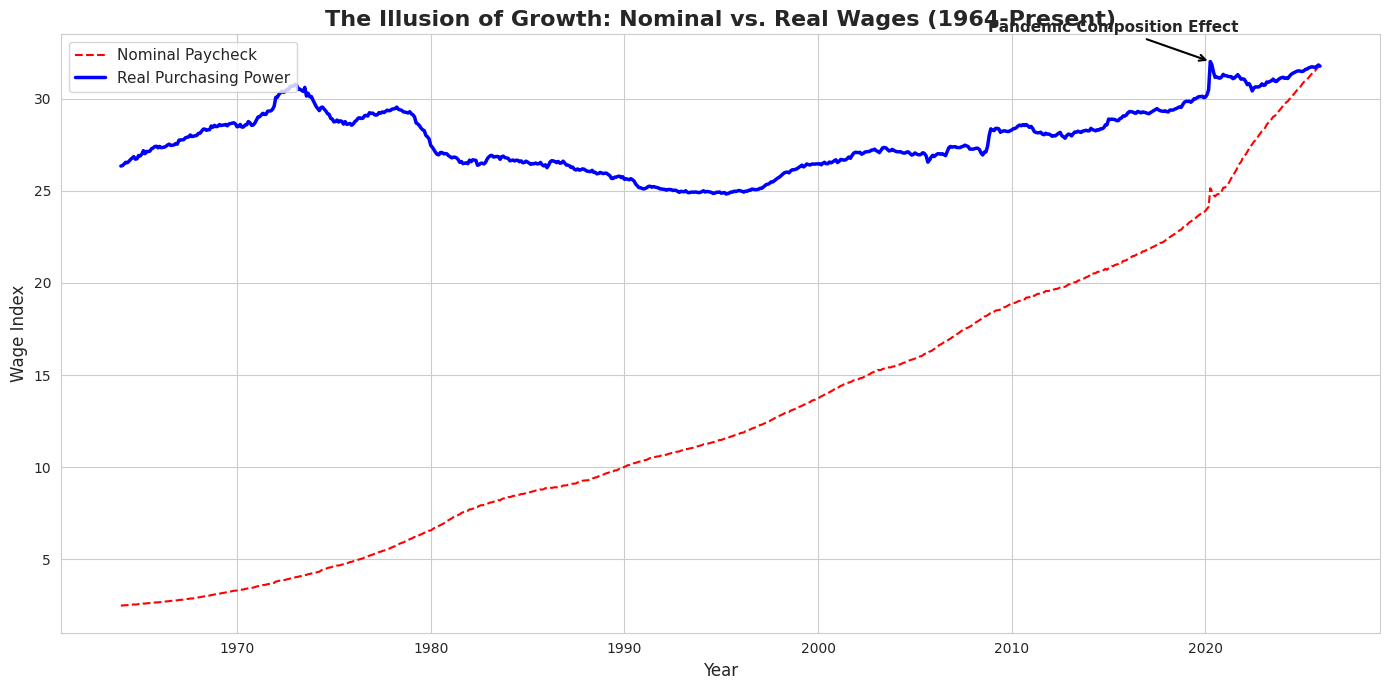

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the seaborn whitegrid theme
sns.set_style("whitegrid")

# Create the figure and axis
fig, ax = plt.subplots(figsize=(14, 7))

# Plot Nominal Wage as a dashed red line
ax.plot(df.index, df['Nominal_Wage'],
        color='red',
        linestyle='--',
        linewidth=1.5,
        label='Nominal Paycheck')

# Plot Real Wage as a thick blue line
ax.plot(df.index, df['Real_Wage'],
        color='blue',
        linestyle='-',
        linewidth=2.5,
        label='Real Purchasing Power')

# Add the title
ax.set_title("The Illusion of Growth: Nominal vs. Real Wages (1964-Present)",
             fontsize=16,
             fontweight='bold')

# Add annotation arrow pointing to 2020 spike
# Find the 2020 data point for positioning
spike_date = df.loc['2020'].idxmax()['Real_Wage'] if hasattr(df.loc['2020'], 'idxmax') else df.loc['2020-04-01':'2020-06-01']['Real_Wage'].idxmax()
spike_value = df.loc[spike_date, 'Real_Wage']

ax.annotate('Pandemic Composition Effect',
            xy=(spike_date, spike_value),
            xytext=(spike_date - pd.DateOffset(years=5), spike_value * 1.05),
            fontsize=11,
            fontweight='bold',
            arrowprops=dict(arrowstyle='->',
                           color='black',
                           lw=1.5),
            ha='center')

# Add axis labels
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Wage Index', fontsize=12)

# Add legend
ax.legend(loc='upper left', fontsize=11, frameon=True)

# Tight layout for clean spacing
plt.tight_layout()

# Display the plot
plt.show()

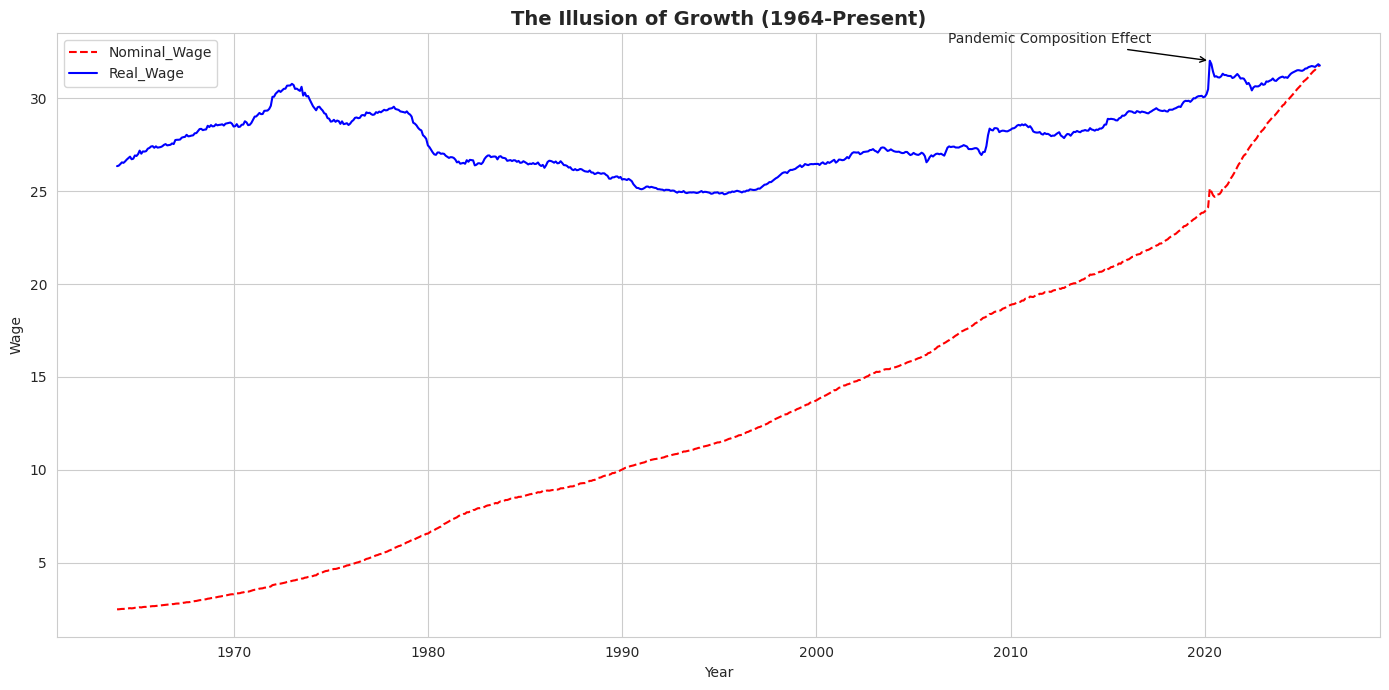

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Create the figure
fig, ax = plt.subplots(figsize=(14, 7))

# Plot both wage series
ax.plot(df.index, df['Nominal_Wage'], color='red', linestyle='--', label='Nominal_Wage')
ax.plot(df.index, df['Real_Wage'], color='blue', linestyle='-', label='Real_Wage')

# Add title
ax.set_title("The Illusion of Growth (1964-Present)", fontsize=14, fontweight='bold')

# Annotate the 2020 spike
spike_date = pd.Timestamp('2020-04-01')
spike_value = df.loc[spike_date, 'Real_Wage']

ax.annotate('Pandemic Composition Effect',
            xy=(spike_date, spike_value),
            xytext=(pd.Timestamp('2012-01-01'), spike_value * 1.03),
            fontsize=10,
            arrowprops=dict(arrowstyle='->', color='black'),
            ha='center')

# Add legend and labels
ax.set_xlabel('Year')
ax.set_ylabel('Wage')
ax.legend()

plt.tight_layout()
plt.show()

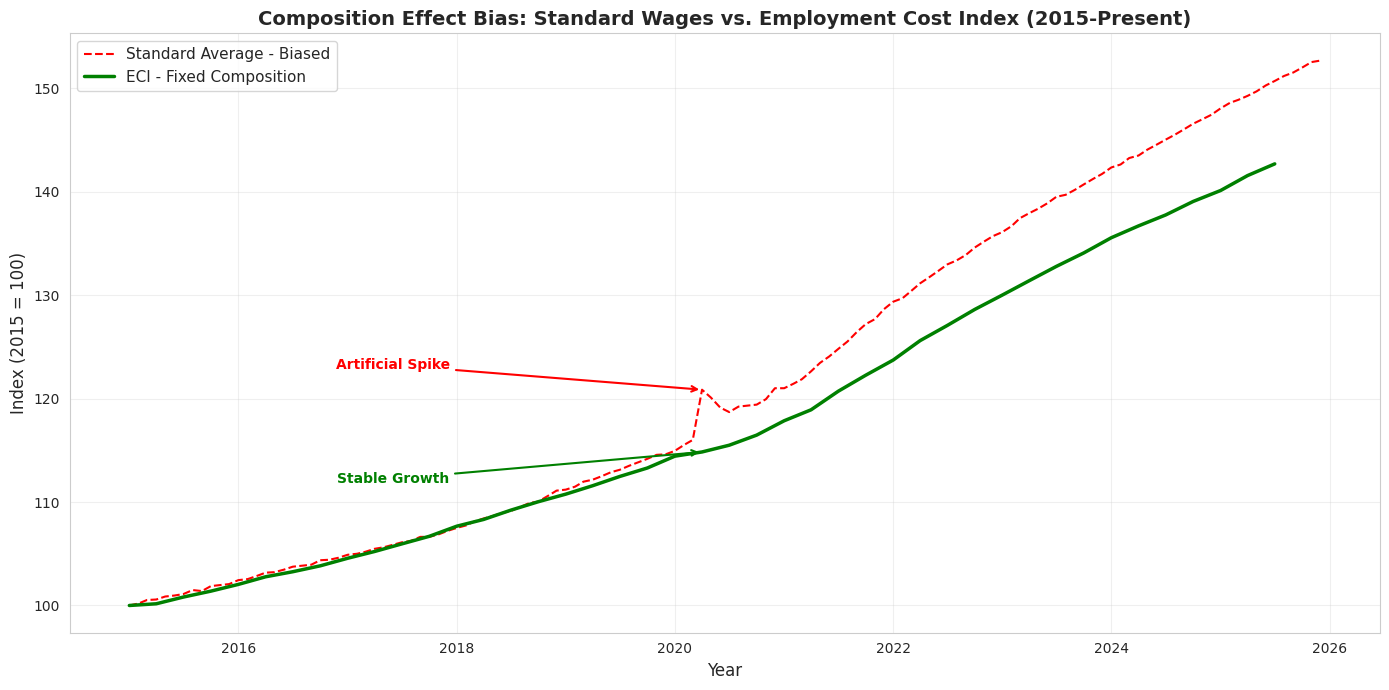

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Fetch the Employment Cost Index from FRED
eci = fred.get_series('ECIWAG')

# 2. Filter both series from 2015-01-01 onwards
start_date = '2015-01-01'
wages_filtered = wages[wages.index >= start_date]
eci_filtered = eci[eci.index >= start_date]

# 3. Rebase both series to 100 (first value = 100)
wages_rebased = (wages_filtered / wages_filtered.iloc[0]) * 100
eci_rebased = (eci_filtered / eci_filtered.iloc[0]) * 100

# 4. Create the plot
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(wages_rebased.index, wages_rebased,
        color='red',
        linestyle='--',
        linewidth=1.5,
        label='Standard Average - Biased')

ax.plot(eci_rebased.index, eci_rebased,
        color='green',
        linestyle='-',
        linewidth=2.5,
        label='ECI - Fixed Composition')

# Add title and labels
ax.set_title("Composition Effect Bias: Standard Wages vs. Employment Cost Index (2015-Present)",
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Index (2015 = 100)', fontsize=12)

# 5. Annotate the divergence in 2020
# Annotation for the artificial spike in standard wages
spike_date = pd.Timestamp('2020-04-01')
ax.annotate('Artificial Spike',
            xy=(spike_date, wages_rebased.loc[spike_date]),
            xytext=(pd.Timestamp('2017-06-01'), wages_rebased.loc[spike_date] + 2),
            fontsize=10,
            fontweight='bold',
            color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            ha='center')

# Annotation for stable growth in ECI
ax.annotate('Stable Growth',
            xy=(spike_date, eci_rebased.loc[spike_date]),
            xytext=(pd.Timestamp('2017-06-01'), eci_rebased.loc[spike_date] - 3),
            fontsize=10,
            fontweight='bold',
            color='green',
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
            ha='center')

# Add legend
ax.legend(loc='upper left', fontsize=11)

# Add grid for readability
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()